<a href="https://www.kaggle.com/code/shreeyashah/yoga-pose-classification?scriptVersionId=317017830" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ujjwalchowdhury/yoga-pose-classification/YogaPoses/Downdog/00000030.jpg
/kaggle/input/datasets/ujjwalchowdhury/yoga-pose-classification/YogaPoses/Downdog/00000027.jpg
/kaggle/input/datasets/ujjwalchowdhury/yoga-pose-classification/YogaPoses/Downdog/00000127.jpg
/kaggle/input/datasets/ujjwalchowdhury/yoga-pose-classification/YogaPoses/Downdog/00000335.jpg
/kaggle/input/datasets/ujjwalchowdhury/yoga-pose-classification/YogaPoses/Downdog/00000115.jpg
/kaggle/input/datasets/ujjwalchowdhury/yoga-pose-classification/YogaPoses/Downdog/00000089.jpg
/kaggle/input/datasets/ujjwalchowdhury/yoga-pose-classification/YogaPoses/Downdog/00000048.jpg
/kaggle/input/datasets/ujjwalchowdhury/yoga-pose-classification/YogaPoses/Downdog/00000033.jpg
/kaggle/input/datasets/ujjwalchowdhury/yoga-pose-classification/YogaPoses/Downdog/00000325.jpg
/kaggle/input/datasets/ujjwalchowdhury/yoga-pose-classification/YogaPoses/Downdog/00000016.jpg
/kaggle/input/datasets/ujjwalchowdhury/yoga-pose-c

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential

2026-05-06 09:16:59.008384: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778059019.031529     128 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778059019.039030     128 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778059019.057298     128 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778059019.057323     128 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778059019.057326     128 computation_placer.cc:177] computation placer alr

# Loading the data

In [4]:
# generators
train_ds, validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/kaggle/input/datasets/ujjwalchowdhury/yoga-pose-classification/YogaPoses',
    validation_split = 0.2,
    subset="both",
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 16,
    image_size = (226, 226),
    seed=1337
)

Found 988 files belonging to 5 classes.
Using 791 files for training.
Using 197 files for validation.


I0000 00:00:1778059046.575907     128 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778059046.581872     128 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# Visualising the training data

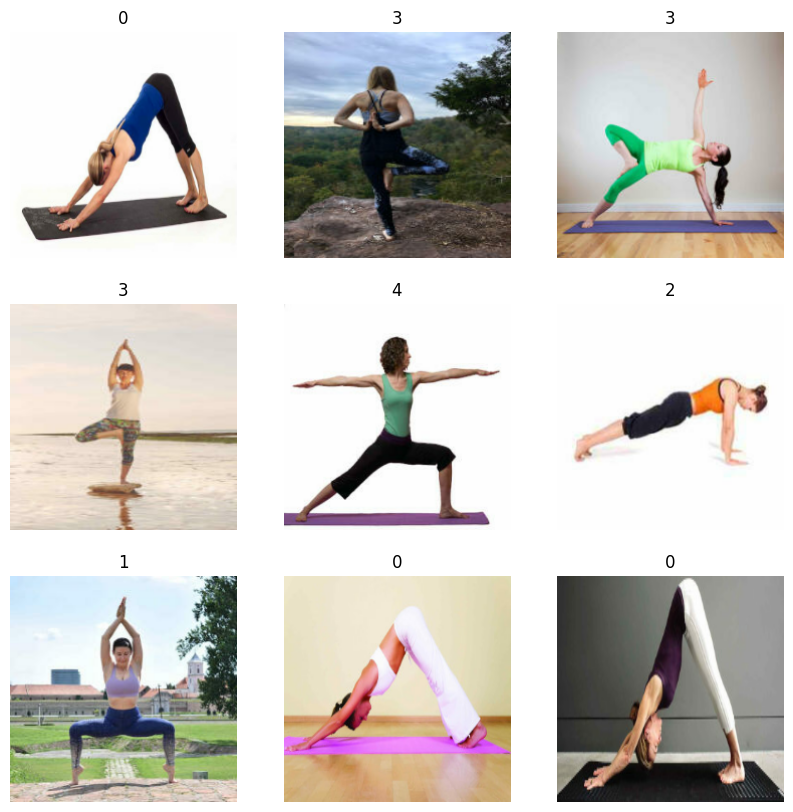

In [5]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

# Data augmentation

In [6]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
])

In [7]:
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Rescaling, Dropout, Flatten, BatchNormalization

In [8]:
model = Sequential()

model.add(Input(shape=(227,227,3)))
model.add(data_augmentation)

model.add(Rescaling(1./255))

model.add(Conv2D(32, kernel_size = (3, 3), strides= (1,1), padding = 'valid', activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides = 2,padding = 'valid' ))

model.add(Conv2D(64, kernel_size = (3, 3), strides= (1,1), padding = 'valid',  activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides = 2,padding = 'valid'))

model.add(Conv2D(128, kernel_size = (3, 3), strides= (1,1), padding = 'valid',  activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides = 2,padding = 'valid'))

model.add(Flatten())

model.add(Dense(128, activation ='relu'))
model.add(Dropout(0.5))

model.add(Dense(64, activation ='relu'))
model.add(Dropout(0.5))

model.add(Dense(5, activation ='softmax'))

In [9]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 227, 227, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 227, 227, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 225, 225, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 225, 225, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 110, 110, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 110, 110, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 55, 55, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 53, 53, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 53, 53, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,178,437 (42.64 MB)

 Trainable params: 11,177,989 (42.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
from keras.optimizers import Adam
model.compile(optimizer = Adam(learning_rate = 1e-4), metrics = ['accuracy'], loss = 'sparse_categorical_crossentropy')

In [ ]:
history = model.fit(train_ds, epochs = 50, validation_data =validation_ds)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.7106 - loss: 0.8558 - val_accuracy: 0.8173 - val_loss: 0.7557
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.7407 - loss: 0.8126 - val_accuracy: 0.8071 - val_loss: 0.7667
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.7595 - loss: 0.7517 - val_accuracy: 0.7513 - val_loss: 0.8001
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.7140 - loss: 0.8227 - val_accuracy: 0.8376 - val_loss: 0.6249
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.7221 - loss: 0.8295 - val_accuracy: 0.8071 - val_loss: 0.6806
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.7243 - loss: 0.8913 - val_accuracy: 0.8426 - val_loss: 0.5934
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.7367 - loss: 0.7862 - val_accuracy: 0.8020 - val_loss: 0.7229
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.7444 - loss: 0.8137 - val_accuracy: 0.8071 - v

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])